# Final project

## Case 1: Clustering cardiovascular diseases patients dataset

Hipothetically the previous model for predicting cardiovascular diseases is not performing well. We want to explore clustering techniques to see if we can find better pacient groups and/or to validate the previous labels.
1. Choose a clustering algorithm and justify your choice.
2. Apply the algorithm to the cardiovascular diseases patients dataset to validate labels.
3. Visualize the clusters and compare them with the original labels to see if we have to relabel the dataset or if we can find better groups of patients.

In [221]:
import pandas as pd

df = pd.read_csv('../lab2/datasets/heart.csv')
print("Dataset size:", df.shape)
df.head()

Dataset size: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### Preparing the data

#### Cleaning

In [222]:
df = df.drop_duplicates(ignore_index=True) # it keeps the first occurrence by default
print("Dataset size after removing duplicates:", df.shape)
df = df[(df['ca'] != 4) & (df['thal'] != 0)]
print("Dataset size after removing inconsistent values:", df.shape)

Dataset size after removing duplicates: (302, 14)
Dataset size after removing inconsistent values: (296, 14)


#### Encoding
We don't need to encode categorical variables as all features are numerical.

### Clustering

In [223]:
from skimpy import skim

skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 296    │ │ int64       │ 13    │                                                          │
│ │ Number of columns │ 14     │ │ float64     │ 1     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━━┓  │
│ ┃ column       ┃ NA   ┃ NA %   ┃ mean      ┃ sd        ┃ p0    ┃ p25   ┃ p50     ┃ p75     ┃ p100  ┃ hist    ┃  │
│ ┡━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━━┩  │
│ │ age          │    0 │      0 │     54.52 │     9.059 │    29 │    48 │      56 │      61 │    77 │ ▁▄▅█▅▁  │  │
│ │ sex          │    0 │      0 │    0.6791 │    0.4676 │     0 │     0 │       1 │       1 │     1 │ ▄    █  │  │
│ │ cp           │    0 │      0 │    0.9595 │     1.034 │     0 │     0 │       1 │       2 │     3 │ █ ▃ ▅▁  │  │
│ │ trestbps     │    0 │      0 │     131.6 │     17.73 │    94 │   120 │     130 │     140 │   200 │  ▃▇█▃▁  │  │
│ │ chol         │    0 │      0 │     247.2 │     51.98 │   126 │   211 │   242.5 │   275.2 │   564 │   ▂█▃   │  │
│ │ fbs          │    0 │      0 │    0.1453 │     0.353 │     0 │     0 │       0 │       0 │     1 │ █    ▁  │  │
│ │ restecg      │    0 │      0 │    0.5236 │    0.5267 │     0 │     0 │       1 │       1 │     2 │  █  █   │  │
│ │ thalach      │    0 │      0 │     149.6 │     22.97 │    71 │   133 │   152.5 │     166 │   202 │  ▂▄██▁  │  │
│ │ exang        │    0 │      0 │    0.3277 │    0.4702 │     0 │     0 │       0 │       1 │     1 │ █    ▄  │  │
│ │ oldpeak      │    0 │      0 │     1.059 │     1.166 │     0 │     0 │     0.8 │    1.65 │   6.2 │  █▃▁▁   │  │
│ │ slope        │    0 │      0 │     1.395 │    0.6182 │     0 │     1 │       1 │       2 │     2 │ ▁  █ █  │  │
│ │ ca           │    0 │      0 │    0.6791 │    0.9397 │     0 │     0 │       0 │       1 │     3 │ █ ▃ ▂▁  │  │
│ │ thal         │    0 │      0 │     2.328 │    0.5857 │     1 │     2 │       2 │       3 │     3 │ ▁  █ ▆  │  │
│ │ target       │    0 │      0 │    0.5405 │    0.4992 │     0 │     0 │       1 │       1 │     1 │ ▇    █  │  │
│ └──────────────┴──────┴────────┴───────────┴───────────┴───────┴───────┴─────────┴─────────┴───────┴─────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

We validate labels using K-Means clustering algorithm.

In [224]:
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
import numpy as np
RNG = 42

X = df.drop(columns=['target'])
# We have to remove the label column for clustering
y = df['target']

# Cluster validation with K=2 (since we have 2 classes, target 0(no disease) and 1 (disease))
kmeans = KMeans(n_clusters=2, random_state=RNG)
labels = kmeans.fit_predict(X)

# We compare the clustering labels with the actual labels
accuracy = np.mean(labels == y)
print(f"Clustering accuracy with 2 clusters: {accuracy:.4f}")

Clustering accuracy with 2 clusters: 0.4257


This means that the labels found by the clustering algorithm will be compared to the original labels in the dataset to see if they match or if there are significant differences. If the clusters found by K-Means align well with the original labels, it suggests that the original labeling is valid. However, if there are discrepancies, it may indicate that the original labels need to be revised or that there are better ways to group the patients based on their features.
> We get 0.4257 accuracy, so we can say that the original labels are not very reliable and we could consider relabeling the dataset based on the clusters found by K-Means, as some pacients might have been misclassified.

Now we will evaluate different values of K to find the best one using silhouette score and elbow method.

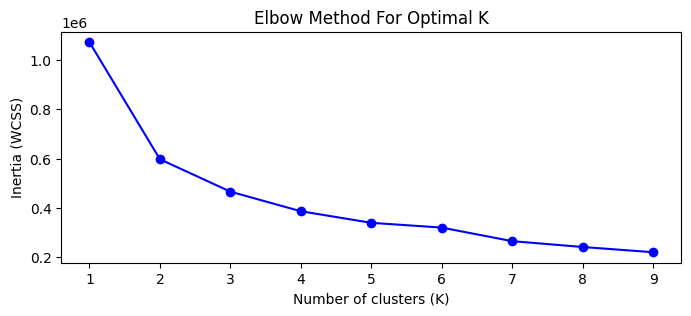

In [225]:
wcss = []
max_k = 10
for k in range(1, max_k):
    kmeans = KMeans(n_clusters=k, random_state=RNG, n_init=1)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 3))
plt.plot(range(1, max_k), wcss, 'bo-')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.show()

We are not sure, after evaluating the elbow method if K=2 or K=3 is better, so we will use silhouette score to evaluate different values of K.

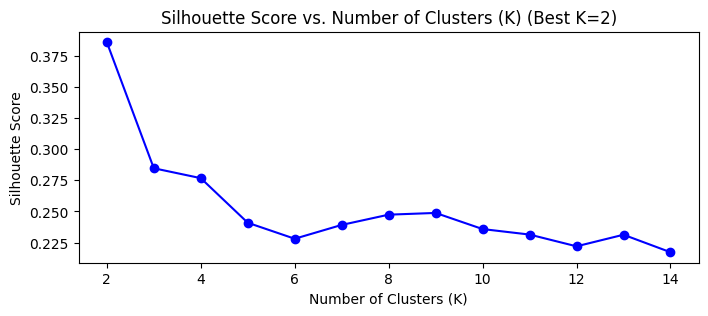

In [226]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from matplotlib import pyplot as plt
import numpy as np
RNG = 42

max_k = 15
kmeans_per_k = [KMeans(n_clusters=k, random_state=RNG).fit(X) for k in range(1, max_k)]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

plt.figure(figsize=(8, 3))
# bo- means blue color, circle marker, solid line
plt.plot(range(2, max_k), silhouette_scores, 'bo-')
plt.title(f'Silhouette Score vs. Number of Clusters (K) (Best K={np.argmax(silhouette_scores)+2})')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.show()

We see that the best K is 2, so we validate that despite having missclassified some pacients, the original cluster is the best one.

## Case 2: Clustering stress levels dataset

The previous regression model is working but the company wants you to explore clustering techniques to find which factors are more related to stress levels and provide additional insights about the data.
1. Choose a clustering algorithm and which can be used to find relations between features and stress levels. Justify your choice. Find the most relevant feature related to stress levels.
2. Is this the same feature that were used in the regression model? Why (not)?
3. Find which features are more related to stress levels using the clustering algorithm. Using the 3 stress levels (low, medium, high) visualize the clusters and provide insights about the data.

In [227]:
import pandas as pd

df = pd.read_csv('../lab2/datasets/Sleep_health_and_lifestyle_dataset.csv')
print("Dataset size:", df.shape)
df.head()

Dataset size: (374, 13)


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


### Preparing the data

#### Cleaning

Dataset modifications:
- Removed the 'Person ID' column as it does not provide useful information for clustering.
- Fill NAs with "No Disorder" in Sleep Disorder column.
- Fix wrong category in BMI Category (Normal Weight instead of Normal).
- Divided BloodPressure into Systolic and Diastolic.

In [228]:
df.drop(labels=['Person ID'], axis=1, inplace=True)
# Not really a NaN, so we fill it with 'No Disorder'
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('No Disorder')
df['BMI Category'] = df['BMI Category'].str.replace('Normal Weight', 'Normal')
df['BMI Category'].value_counts()
# Blood Pressure as it's in reality two numerical features together
splitted_bp = df['Blood Pressure'].str.split('/', expand=True)
systolic = splitted_bp[0].astype(float)
diastolic = splitted_bp[1].astype(float)
df['Blood Pressure Systolic'] = systolic
df['Blood Pressure Diastolic'] = diastolic
df.drop(labels=['Blood Pressure'], axis=1, inplace=True)

#### Encoding

Dataset modifications:
- Encode categorical variables: 'Gender', 'BMI Category', 'Sleep Disorder', 'Occupation'.
- Normalize numerical features.

In [229]:
from sklearn.preprocessing import LabelEncoder

ordinal_features = ['BMI Category', 'Sleep Disorder']
nominal_features = ['Gender', 'Occupation']

for feature in ordinal_features:
    le = LabelEncoder()
    df[feature] = le.fit_transform(df[feature])

df = pd.get_dummies(df, columns=nominal_features, drop_first=False)

In [230]:
# from sklearn.preprocessing import MinMaxScaler

# numerical_columns = ['Age', 'Sleep Duration', 'Physical Activity Level',
#                      'Quality of Sleep', 'Heart Rate', 'Daily Steps',
#                      'Blood Pressure Systolic', 'Blood Pressure Diastolic']
# scaler = MinMaxScaler()
# df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

### Clustering

In [231]:
from skimpy import skim

skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 374    │ │ bool        │ 13    │                                                          │
│ │ Number of columns │ 24     │ │ int64       │ 8     │                                                          │
│ └───────────────────┴────────┘ │ float64     │ 3     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column                  ┃ NA  ┃ NA %  ┃ mean    ┃ sd      ┃ p0    ┃ p25    ┃ p50   ┃ p75  ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ Age                     │   0 │     0 │   42.18 │   8.673 │    27 │  35.25 │    43 │   50 │    59 │ ▇▆▆█▆▄ │  │
│ │ Sleep Duration          │   0 │     0 │   7.132 │  0.7957 │   5.8 │    6.4 │   7.2 │  7.8 │   8.5 │ ▇▇▃▆█▆ │  │
│ │ Quality of Sleep        │   0 │     0 │   7.313 │   1.197 │     4 │      6 │     7 │    8 │     9 │  ▁█▆█▅ │  │
│ │ Physical Activity Level │   0 │     0 │   59.17 │   20.83 │    30 │     45 │    60 │   75 │    90 │ ██▁▇▇▇ │  │
│ │ Stress Level            │   0 │     0 │   5.385 │   1.775 │     3 │      4 │     5 │    7 │     8 │ ███▅▆█ │  │
│ │ BMI Category            │   0 │     0 │  0.8182 │  0.9709 │     0 │      0 │     0 │    2 │     2 │ █    ▅ │  │
│ │ Heart Rate              │   0 │     0 │   70.17 │   4.136 │    65 │     68 │    70 │   72 │    86 │  █▄▅   │  │
│ │ Daily Steps             │   0 │     0 │    6817 │    1618 │  3000 │   5600 │  7000 │ 8000 │ 10000 │ ▁▆▆▆█▃ │  │
│ │ Sleep Disorder          │   0 │     0 │   1.003 │  0.6446 │     0 │      1 │     1 │    1 │     2 │ ▃  █ ▃ │  │
│ │ Blood Pressure Systolic │   0 │     0 │   128.6 │   7.748 │   115 │    125 │   130 │  135 │   142 │ ▃▃▆█▂▅ │  │
│ │ Blood Pressure          │   0 │     0 │   84.65 │   6.162 │    75 │     80 │    85 │   90 │    95 │ ▃█▁█▂▅ │  │
│ │ Diastolic               │     │       │         │         │       │        │       │      │       │        │  │
│ └─────────────────────────┴─────┴───────┴─────────┴─────────┴───────┴────────┴───────┴──────┴───────┴────────┘  │
│                                                      bool                                                       │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓  │
│ ┃ column                                           ┃ true         ┃ true rate              ┃ hist            ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩  │
│ │ Gender_Female                                    │          185 │                   0.49 │     █    █      │  │
│ │ Gender_Male                                      │          189 │                   0.51 │     █    █      │  │
│ │ Occupation_Accountant                            │           37 │                  0.099 │     █    ▁      │  │
│ │ Occupation_Doctor                                │           71 │                   0.19 │     █    ▂      │  │
│ │ Occupation_Engineer                              │  

We use PCA to see which features are more related to stress levels.

In [232]:
from matplotlib import pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
RNG = 42

X_original = df.drop(columns=['Stress Level'])
# We have to remove the label column for clustering
y = df['Stress Level']

X = MinMaxScaler().fit_transform(X_original)
X = pd.DataFrame(X, columns=X_original.columns)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RNG)

In [236]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

data = X_original[sorted(X_original.columns)]

# We standardize the data before applying PCA
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

pca = PCA(n_components=0.95)  # Keep 95% of variance
pca.fit(data_scaled)

importance = pd.DataFrame(
    pca.components_,
    columns=data.columns,
    index=[f'PC{i+1}' for i in range(pca.n_components_)]
)

importance.T

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
Age,0.355834,0.176071,-0.085945,-0.223730,-0.044994,-0.183856,-0.072800,0.008070,-0.029707,0.013234,-0.110568,-0.018654,0.029582
BMI Category,0.319209,-0.239571,-0.217889,-0.099949,0.109446,-0.090209,-0.051547,0.019517,0.038675,0.022373,0.002347,-0.229109,0.092313
Blood Pressure Diastolic,0.383806,-0.185207,0.065859,-0.185768,-0.009572,0.121947,0.003854,-0.021871,0.001200,-0.010911,-0.040994,-0.014632,0.143220
Blood Pressure Systolic,0.356862,-0.192884,0.027338,-0.264263,-0.074850,0.120443,0.056977,-0.012345,-0.025617,-0.008576,-0.081614,0.087610,0.173594
Daily Steps,0.131985,-0.008119,0.398326,0.154933,0.375060,-0.038443,-0.096725,0.029764,0.020522,-0.027024,0.432412,-0.025196,-0.275109
Gender_Female,0.299800,0.212657,-0.252462,0.296022,-0.000459,0.033451,0.025465,0.012210,0.002880,0.000552,-0.034060,0.066746,-0.093157
Gender_Male,-0.299800,-0.212657,0.252462,-0.296022,0.000459,-0.033451,-0.025465,-0.012210,-0.002880,-0.000552,0.034060,-0.066746,0.093157
Heart Rate,0.037071,-0.382316,0.110024,0.160871,-0.269777,-0.160839,0.136734,-0.019854,0.027723,0.022937,-0.054327,0.205166,0.465833
Occupation_Accountant,-0.062474,0.165018,-0.121155,0.437811,0.245990,-0.361715,0.227962,-0.145707,-0.152951,-0.044569,-0.086163,0.018326,0.349070
Occupation_Doctor,-0.229897,-0.120985,0.174257,0.176093,-0.141726,0.224709,-0.510957,0.021659,-0.027389,0.056479,-0.287128,-0.227721,0.109911


We see after using PCA that the most relevant features related to stress levels are Age, BMI Category, Blood Pressure Diastolic/Systolic, Daily Steps and Gender Female/Male.

We repeat feature importance but we a regression model instead of clustering.

Linear Regression RMSE: 0.37
Linear Regression MAE: 0.22
Linear Regression R²: 0.96


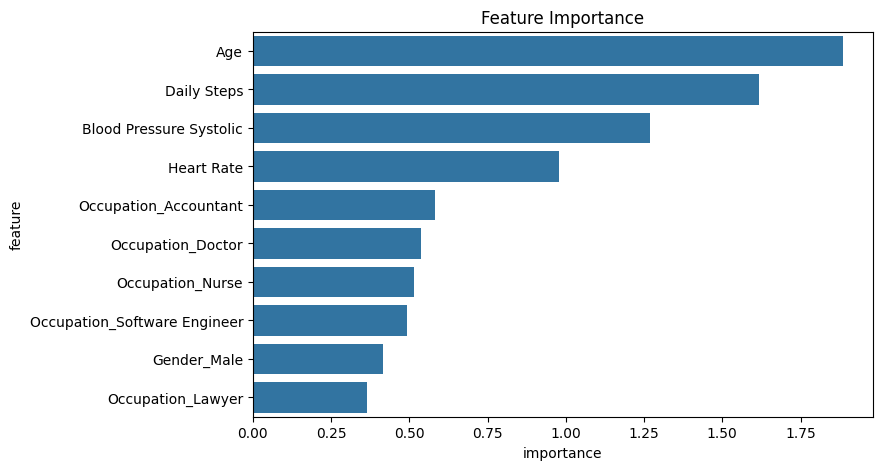

In [237]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import seaborn as sns

lm = LinearRegression()
lm.fit(X_train, y_train)
y_pred_reg = lm.predict(X_test)

mse = mean_squared_error(y_test, y_pred_reg)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_reg)
r2 = r2_score(y_test, y_pred_reg)

print(f'Linear Regression RMSE: {rmse:.2f}')
print(f'Linear Regression MAE: {mae:.2f}')
print(f'Linear Regression R²: {r2:.2f}')

feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lm.coef_
}).sort_values(by='importance', ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(data=feat_imp.head(10), y='feature', x='importance')
plt.title("Feature Importance")
plt.show()

We see that the most relevant feature related to stress levels are Age, Daily Steps and Blood Pressure Systolic, which are also some of the features found using PCA. But after that there are some differences, as PCA found BMI Category, Blood Pressure Diastolic and Gender, while linear regression found Heart Rate and ºOccupation more significant.

Now we will group the stress levels into 3 categories: low, medium and high, and visualize the clusters using the most relevant features found before.

In [ ]:
df['Stress Level'] = df['Stress Level'].replace([0, 1, 2, 3], 'No Stressed')
df['Stress Level'] = df['Stress Level'].replace([4, 5, 6], 'Stressed')
df['Stress Level'] = df['Stress Level'].replace([7, 8], 'Extremely Stressed')

In [238]:
df['Stress Level'] = le.fit_transform(df['Stress Level'])

X_original = df.drop('Stress Level', axis=1)
y = df['Stress Level']

X = MinMaxScaler().fit_transform(X_original)
X = pd.DataFrame(X, columns=X_original.columns)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [239]:
data = X_original[sorted(X_original.columns)]

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

pca = PCA(n_components=0.95)
pca.fit(data_scaled)

importance = pd.DataFrame(
    pca.components_,
    columns=data.columns,
    index=[f'PC{i+1}' for i in range(pca.n_components_)]
)

importance.T

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
Age,0.355834,0.176071,-0.085945,-0.223730,-0.044994,-0.183856,-0.072800,0.008070,-0.029707,0.013234,-0.110568,-0.018654,0.029582
BMI Category,0.319209,-0.239571,-0.217889,-0.099949,0.109446,-0.090209,-0.051547,0.019517,0.038675,0.022373,0.002347,-0.229109,0.092313
Blood Pressure Diastolic,0.383806,-0.185207,0.065859,-0.185768,-0.009572,0.121947,0.003854,-0.021871,0.001200,-0.010911,-0.040994,-0.014632,0.143220
Blood Pressure Systolic,0.356862,-0.192884,0.027338,-0.264263,-0.074850,0.120443,0.056977,-0.012345,-0.025617,-0.008576,-0.081614,0.087610,0.173594
Daily Steps,0.131985,-0.008119,0.398326,0.154933,0.375060,-0.038443,-0.096725,0.029764,0.020522,-0.027024,0.432412,-0.025196,-0.275109
Gender_Female,0.299800,0.212657,-0.252462,0.296022,-0.000459,0.033451,0.025465,0.012210,0.002880,0.000552,-0.034060,0.066746,-0.093157
Gender_Male,-0.299800,-0.212657,0.252462,-0.296022,0.000459,-0.033451,-0.025465,-0.012210,-0.002880,-0.000552,0.034060,-0.066746,0.093157
Heart Rate,0.037071,-0.382316,0.110024,0.160871,-0.269777,-0.160839,0.136734,-0.019854,0.027723,0.022937,-0.054327,0.205166,0.465833
Occupation_Accountant,-0.062474,0.165018,-0.121155,0.437811,0.245990,-0.361715,0.227962,-0.145707,-0.152951,-0.044569,-0.086163,0.018326,0.349070
Occupation_Doctor,-0.229897,-0.120985,0.174257,0.176093,-0.141726,0.224709,-0.510957,0.021659,-0.027389,0.056479,-0.287128,-0.227721,0.109911


We changed the categorization of stress levels, but the features that are more related to stress levels remain the same in PCA.

Linear Regression RMSE: 0.37
Linear Regression MAE: 0.22
Linear Regression R²: 0.96


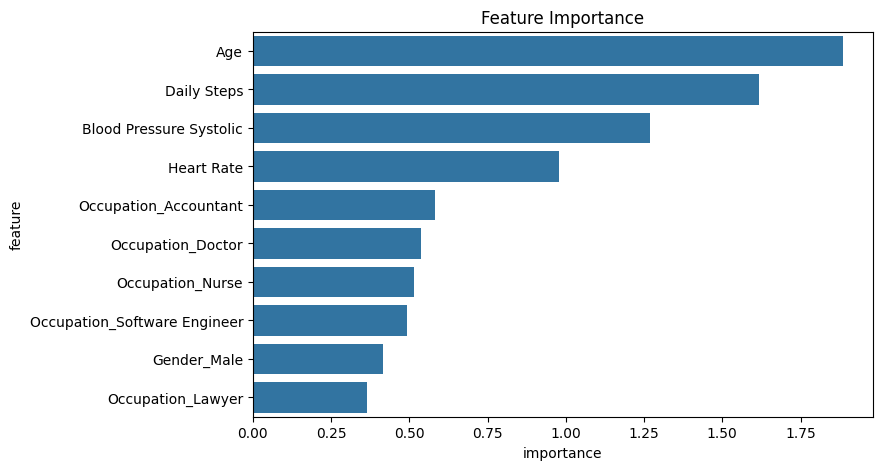

In [240]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import seaborn as sns

lm = LinearRegression()
lm.fit(X_train, y_train)
y_pred_reg = lm.predict(X_test)

mse = mean_squared_error(y_test, y_pred_reg)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_reg)
r2 = r2_score(y_test, y_pred_reg)

print(f'Linear Regression RMSE: {rmse:.2f}')
print(f'Linear Regression MAE: {mae:.2f}')
print(f'Linear Regression R²: {r2:.2f}')

feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lm.coef_
}).sort_values(by='importance', ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(data=feat_imp.head(10), y='feature', x='importance')
plt.title("Feature Importance")
plt.show()

Similar for linear regression.

So we can conclude that despise recategorizing stress levels, the most relevant features related to stress levels remain the same.